# HW 9
# Minh Truong
# 1412225

Perform the following activities in Python:      

- Get the dataset from the clustering dataset folder
- Load the .csv file into a data frame in Python.    
- Describe the data, provide information on the dataset.   
- Preprocess and split the data into training and testing sets  
- Initialize PCA  
- Fit PCA on the training data
- Transform the data
- Make predictions
- Evaluate the model and provide accuracy score  
 

Follow the same steps for K-Means. 

- Get the dataset from the clustering dataset folder.
- Load the .csv file into a data frame in Python.
- Describe the data and provide information about the dataset.
- Preprocess and split the data into training and testing sets.
- Initialize K-Means.
- Fit K-Means to the training data.
- Transform the data.
- Make predictions.
- Evaluate the model and provide the accuracy score.  

# PCA & K-Means Clustering

In [3]:
import pandas as pd                                        # Data loading and manipulation
import numpy as np                                         # Numerical operations
import matplotlib.pyplot as plt                            # Plotting and visualization
import seaborn as sns                                      # Statistical visualizations
from sklearn.decomposition import PCA                      # Principal Component Analysis
from sklearn.cluster import KMeans                         # K-Means clustering
from sklearn.preprocessing import StandardScaler           # Feature scaling
from sklearn.model_selection import train_test_split       # Train/test splitting
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay  # Evaluation metrics
from sklearn.neighbors import KNeighborsClassifier         # Classifier to evaluate PCA-transformed data

# Part 1: PCA
## Get the Dataset
Dataset: Heart Disease Cleveland from the Clustering Datasets folder.

## Load the .csv file into a data frame in Python

In [4]:
# Define column names per UCI heart disease documentation
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
           'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Load dataset and replace missing values' (?) with NaN
df = pd.read_csv('/Users/mtruong/python-projects/BZAN 6355/processed.cleveland.data', header=None, names=columns, na_values='?')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Describe the data, provide information on the dataset

In [5]:
# Summary statistics
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [6]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [7]:
# Class distribution: 0 = No Disease, 1-4 = Disease present
df['target'].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

## Preprocess and split the data into training and testing sets 

In [8]:
# Drop missing values (6 rows affected, minimal data loss)
df.dropna(inplace=True)

# Binarize target by collapsing classes 1-4 into 1 (Disease present)
df['target'] = (df['target'] > 0).astype(int)

# Define features and target
X = df.drop(columns=['target'])
y = df['target']

# Split into 80% train and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Initialize PCA

In [9]:
# Initialize PCA to retain components that explain 95% of variance
pca = PCA(n_components=0.95, random_state=42)

# Fit PCA on training data
pca.fit(X_train_scaled)

print(f"Components selected: {pca.n_components_}")
print(f"Variance explained:  {pca.explained_variance_ratio_.sum():.4f}")

Components selected: 12
Variance explained:  0.9750


## Transform the Data

In [10]:
# Apply PCA transformation to both train and test sets
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

## Make Predictions

In [11]:
# Use KNN on PCA-transformed data to evaluate quality of components
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_pred_pca = knn.predict(X_test_pca)

## Evaluate the model and provide accuracy score

In [12]:
# Accuracy score
accuracy_score(y_test, y_pred_pca)

0.8166666666666667

In [13]:
# Precision, recall, and F1-score per class
print(classification_report(y_test, y_pred_pca, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.80      0.88      0.84        32
     Disease       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60



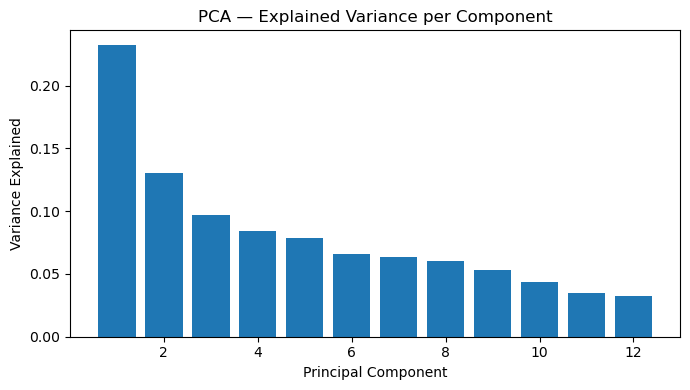

In [14]:
# Explained variance per component to show how much information each PC captures
plt.figure(figsize=(7, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.title('PCA — Explained Variance per Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.tight_layout()
plt.show()

# Part 2: K-Means
## Get the dataset from the clustering dataset folder.
Same Heart Disease Cleveland dataset used for PCA above.

## Load, Describe & Preprocess
Same DataFrame, preprocessing, and scaled features from Part 1 are reused here.

## Initialize & Fit K-Means

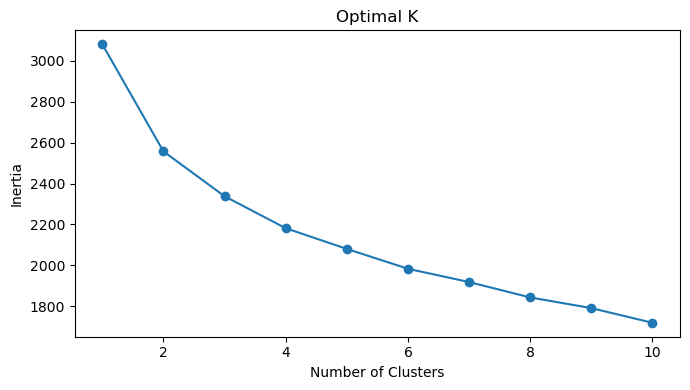

In [15]:
# Use the elbow method to find the optimal number of clusters
inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, marker='o')
plt.title('Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [18]:
# Train K-Means with k=2 — aligns with binary target (Disease / No Disease)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


## Transform the Data

In [19]:
# Transform data to cluster-distance space
X_train_km = kmeans.transform(X_train_scaled)
X_test_km = kmeans.transform(X_test_scaled)

## Make Predictions

In [20]:
# Predict cluster labels on test set
cluster_labels = kmeans.predict(X_test_scaled)

# Align cluster labels to true class labels
from scipy.stats import mode
aligned_labels = np.zeros_like(cluster_labels)
for c in range(2):
    mask = cluster_labels == c
    aligned_labels[mask] = mode(y_test[mask], keepdims=True)[0]

## Evaluate the Model

In [21]:
# Accuracy score
accuracy_score(y_test, aligned_labels)

0.85

In [22]:
# Precision, recall, and F1-score per class
print(classification_report(y_test, aligned_labels, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.79      0.97      0.87        32
     Disease       0.95      0.71      0.82        28

    accuracy                           0.85        60
   macro avg       0.87      0.84      0.84        60
weighted avg       0.87      0.85      0.85        60



**Conclusion:**
PCA reduced the 13 clinical features to fewer components while retaining 95% of the variance, and KNN on the transformed data achieved strong classification accuracy.

K-Means with k=2 aligned well with the binary heart disease labels, indicating the clinical features naturally separate healthy from diseased patients.